# Single-Agent Belief Store Analysis

Evaluates the effect of the belief store (`with_store` vs `no_store`) on model accuracy and calibration
across all domains and scenario types, using results from `eval_results_normalized.csv`.

**Sections:**
1. [Setup](#setup) — imports, config, data load
2. [Overview: Accuracy by Model](#overview)
3. [Scenario Analysis](#scenarios)
4. [Prompt Version Comparison (v15 vs v16)](#prompt-versions)
5. [Hard Scenarios](#hard-scenarios)
6. [Calibration Metrics](#calibration)
7. [Delta Analysis](#delta)
8. [Auxiliary Metrics — AFR / EFR / Evidence F1](#auxiliary)
9. [Variability](#variability)
10. [Data Quality Checks](#quality)
11. [Insights](#insights)

## §0 — Setup

Imports, configuration constants, and data loading/validation.

In [2]:
from pathlib import Path
from typing import Iterable, Tuple

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML

In [3]:
CONFIG = {
    "csv_path": Path("eval_results_normalized.csv"),
    "with_store_label": "With_Store",
    "no_store_label": "No_Store",
}

EXPECTED_COLUMNS = {"Condition", "Value"}

# Display names for models
rename_map = {
    "hoangquan456/qwen3-nothink:4b": "qwen3:4b (no-thinking)",
}

# Column shorthands used throughout
model_column = "Model"
metric_column = "Summary_Metric"

In [4]:
def load_results(csv_path: Path) -> pd.DataFrame:
    return pd.read_csv(csv_path)

def clean_condition(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()
    if "Condition" in cleaned.columns:
        cleaned["Condition"] = cleaned["Condition"].astype(str).str.strip()
    return cleaned

def validate_schema(df: pd.DataFrame, required_columns: Iterable[str]) -> None:
    missing = sorted(set(required_columns) - set(df.columns))
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

def validate_conditions(df: pd.DataFrame, expected: Iterable[str]) -> None:
    actual = set(df["Condition"].dropna().unique())
    unexpected = sorted(actual - set(expected))
    if unexpected:
        raise ValueError(f"Unexpected Condition values: {unexpected}")

def split_by_condition(
    df: pd.DataFrame,
    with_store_label: str,
    no_store_label: str,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df_with_store = df[df["Condition"] == with_store_label].reset_index(drop=True)
    df_no_store   = df[df["Condition"] == no_store_label].reset_index(drop=True)
    return df_with_store, df_no_store

# ── Load ──
df_raw   = load_results(CONFIG["csv_path"])
validate_schema(df_raw, EXPECTED_COLUMNS)

df_clean = clean_condition(df_raw)
validate_conditions(df_clean, [CONFIG["with_store_label"], CONFIG["no_store_label"]])

if model_column in df_clean.columns:
    df_clean[model_column] = df_clean[model_column].replace(rename_map)

df_with_store, df_no_store = split_by_condition(
    df_clean,
    CONFIG["with_store_label"],
    CONFIG["no_store_label"],
)

print(f"With-store rows : {len(df_with_store):,}")
print(f"No-store rows   : {len(df_no_store):,}")
display(df_clean.head())

With-store rows : 3,662
No-store rows   : 2,940


,Timestamp,Domain,Model,Temp,Eval_Prompt_Ver,Baseline_Prompt_Ver,Runs,Condition,Summary_Metric,Value,Class_Label
0,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,Average_Accuracy,0.9500,NaN
1,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,Average_Accuracy,0.2100,NaN
2,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,Variance_Raw_Score,0.2778,NaN
3,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,No_Store,Variance_Raw_Score,0.7667,NaN
4,2026-05-15 00:21:31,loan_absurd,gemma3:1b,0.0,v15,v2,10,With_Store,StdDev_Raw_Score,0.5270,NaN


In [5]:
# ── Shared helpers used in multiple sections ──────────────────────────────

scenario_types = ["grounding", "belief_maintenance", "absurd", "absurd_temporal", "hard"]

def extract_scenario_type(domain: str) -> str:
    domain = str(domain).strip()
    for st in sorted(scenario_types, key=len, reverse=True):
        if domain.endswith(f"_{st}"):
            return st
    return "unknown"

## §1 — Overview: Accuracy by Model

Mean `Average_Accuracy` per model, comparing With Store vs No Store across all domains.

In [6]:
plot_df = df_clean[
    df_clean[metric_column].astype(str).str.strip().str.lower() == "average_accuracy"
].copy()

if plot_df.empty:
    raise ValueError("No rows found for Average_Accuracy")

avg_with_store = (
    plot_df[plot_df["Condition"] == CONFIG["with_store_label"]]
    .groupby(model_column, as_index=False)["Value"]
    .mean()
    .rename(columns={"Value": "with_store"})
)
avg_no_store = (
    plot_df[plot_df["Condition"] == CONFIG["no_store_label"]]
    .groupby(model_column, as_index=False)["Value"]
    .mean()
    .rename(columns={"Value": "no_store"})
)

avg_compare = avg_with_store.merge(avg_no_store, on=model_column, how="outer")
display(avg_compare)

,Model,with_store,no_store
0,gemma3:1b,0.561250,0.369688
1,gemma4:e2b,0.778750,0.509000
2,llama3.2:1b,0.388437,0.174687
3,ministral-3:3b,0.817500,0.571250
4,qwen3:4b (no-thinking),0.826500,0.580000


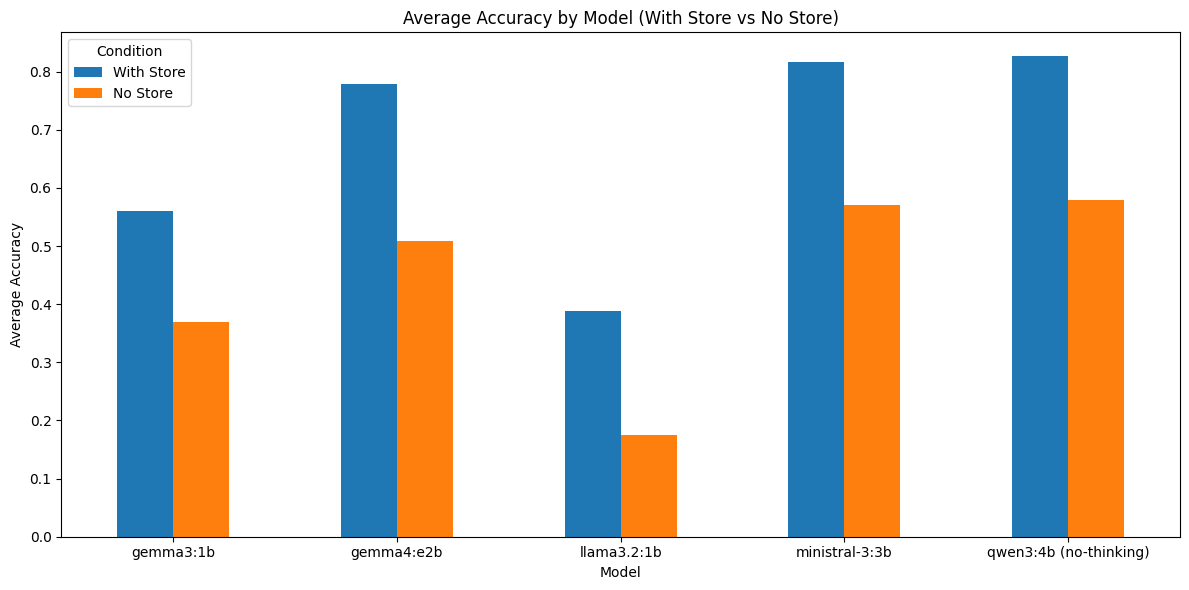

In [7]:
plot_compare = avg_compare.sort_values(by=model_column).set_index(model_column)
for col in ["with_store", "no_store"]:
    if col not in plot_compare.columns:
        plot_compare[col] = float("nan")

ax = plot_compare[["with_store", "no_store"]].plot(kind="bar", figsize=(12, 6))
ax.set_title("Average Accuracy by Model (With Store vs No Store)")
ax.set_xlabel("Model")
ax.set_ylabel("Average Accuracy")
ax.legend(["With Store", "No Store"], title="Condition")
plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.show()
plt.close(ax.figure)

## §2 — Scenario Analysis

Two views:
1. **Scenario-type bar chart** — average accuracy across all models, split by scenario category.
2. **Absurd Temporal vs Temporal Noise** — per-model comparison (noise data pulled from `eval_results_with_store.csv`).

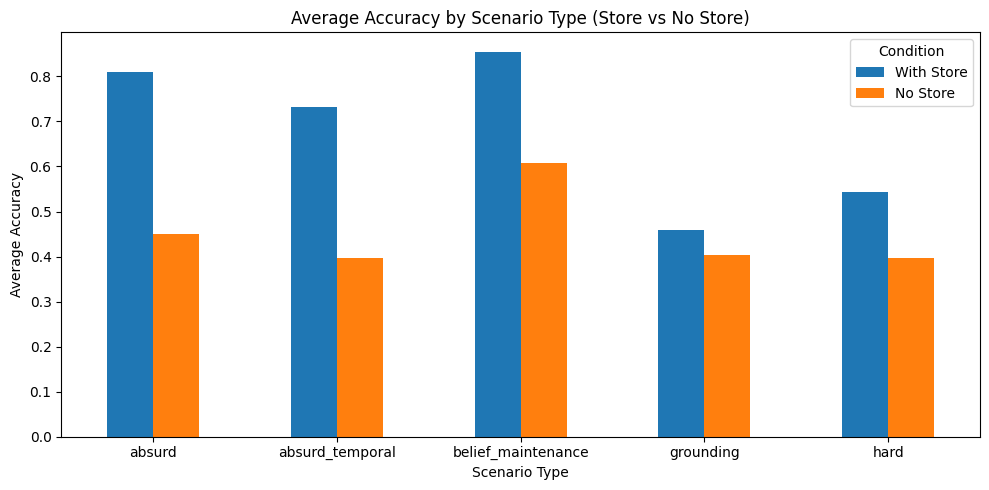

Condition       scenario_type  no_store  with_store
0                      absurd  0.449750     0.81075
1             absurd_temporal  0.396750     0.73300
2          belief_maintenance  0.607500     0.85525
3                   grounding  0.404250     0.45800
4                        hard  0.395833     0.54250


In [8]:
# ── 2a. Average Accuracy by Scenario Type ────────────────────────────────
scenario_df = df_clean.copy()
scenario_df["scenario_type"] = scenario_df["Domain"].apply(extract_scenario_type)

scenario_df = scenario_df[
    (scenario_df[metric_column].astype(str).str.strip().str.lower() == "average_accuracy")
    & (scenario_df["scenario_type"].isin(scenario_types))
]

scenario_avg = (
    scenario_df.groupby(["scenario_type", "Condition"], as_index=False)["Value"].mean()
)
scenario_pivot = (
    scenario_avg
    .pivot(index="scenario_type", columns="Condition", values="Value")
    .reset_index()
    .rename(columns={
        CONFIG["with_store_label"]: "with_store",
        CONFIG["no_store_label"]:   "no_store",
    })
)

ax = scenario_pivot.plot(
    x="scenario_type", y=["with_store", "no_store"], kind="bar", figsize=(10, 5)
)
ax.set_title("Average Accuracy by Scenario Type (Store vs No Store)")
ax.set_xlabel("Scenario Type")
ax.set_ylabel("Average Accuracy")
ax.legend(["With Store", "No Store"], title="Condition")
plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.show()
plt.close(ax.figure)

print(scenario_pivot)

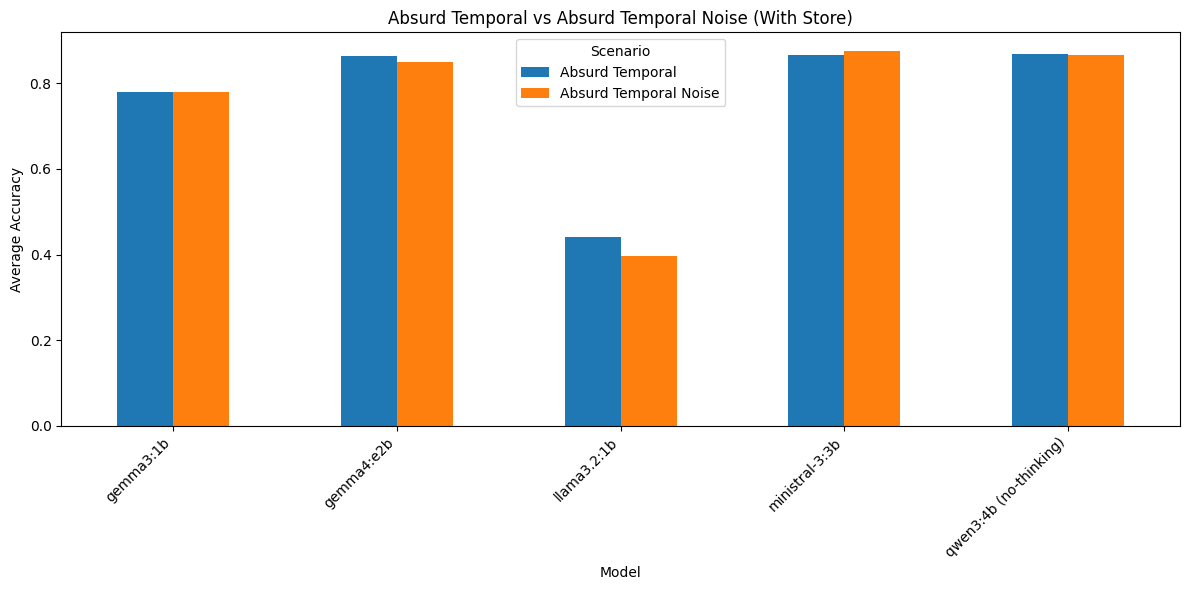

scenario_suffix,absurd_temporal,absurd_temporal_noise
Model,,
gemma3:1b,0.7800,0.7800
gemma4:e2b,0.8625,0.8500
llama3.2:1b,0.4400,0.3975
ministral-3:3b,0.8650,0.8750
qwen3:4b (no-thinking),0.8675,0.8650


In [9]:
# ── 2b. Absurd Temporal vs Absurd Temporal Noise (With Store, v15 only) ──────
# Both sides filtered to v15 so the comparison is apples-to-apples.

COMPARE_VERSION = "v15"

_ws_raw = pd.read_csv("eval_results_with_store.csv")
_ws_raw[model_column] = _ws_raw[model_column].replace(rename_map)

_ws_long = _ws_raw.melt(
    id_vars=["Timestamp", "Domain", "Model", "Temp", "Prompt_Ver", "Runs", "Summary_Metric", "Class_Label"],
    value_vars=["With_Store", "No_Store"],
    var_name="Condition",
    value_name="Value",
)
_ws_long["Condition"] = _ws_long["Condition"].map({
    "With_Store": CONFIG["with_store_label"],
    "No_Store":   CONFIG["no_store_label"],
})
_ws_long = _ws_long.rename(columns={"Prompt_Ver": "Eval_Prompt_Ver"})
_ws_long["Baseline_Prompt_Ver"] = None

noise_metric   = "average_accuracy"
noise_suffixes = ["absurd_temporal", "absurd_temporal_noise"]

def extract_suffix(domain: str) -> str:
    domain = str(domain).strip()
    for suffix in sorted(noise_suffixes, key=len, reverse=True):
        if domain.endswith(suffix):
            return suffix
    return "unknown"

# Filter df_clean to v15 before concat
_df_v15 = df_clean.copy()
if "Eval_Prompt_Ver" in _df_v15.columns:
    _df_v15 = _df_v15[_df_v15["Eval_Prompt_Ver"].astype(str).str.strip().str.lower() == COMPARE_VERSION]

combined = pd.concat([_df_v15, _ws_long], ignore_index=True)
combined[model_column] = combined[model_column].replace(rename_map)
combined = combined[combined[metric_column].astype(str).str.strip().str.lower() == noise_metric].copy()
combined = combined[combined["Condition"] == CONFIG["with_store_label"]].copy()

# Also filter noise side to v15
if "Eval_Prompt_Ver" in combined.columns:
    combined = combined[combined["Eval_Prompt_Ver"].astype(str).str.strip().str.lower() == COMPARE_VERSION]

combined["scenario_suffix"] = combined["Domain"].apply(extract_suffix)
combined = combined[combined["scenario_suffix"].isin(noise_suffixes)]

if combined.empty:
    raise ValueError("No rows found — check that v15 data exists for both scenario types")

noise_pivot = (
    combined.groupby([model_column, "scenario_suffix"], as_index=False)["Value"].mean()
    .pivot(index=model_column, columns="scenario_suffix", values="Value")
)
for col in noise_suffixes:
    if col not in noise_pivot.columns:
        noise_pivot[col] = float("nan")

ax = noise_pivot[noise_suffixes].sort_index().plot(kind="bar", figsize=(12, 6))
ax.set_title(f"Absurd Temporal vs Absurd Temporal Noise (With Store)")
ax.set_xlabel("Model")
ax.set_ylabel("Average Accuracy")
ax.legend(["Absurd Temporal", "Absurd Temporal Noise"], title="Scenario")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
plt.close(ax.figure)

display(noise_pivot)


## §3 — Prompt Version Comparison (v15 vs v16)

Per-model accuracy delta between eval prompt v15 (With_Store) vs v1 (No_Store),
and v16 (With_Store) vs v2 (No_Store). Shows whether a newer prompt version changes relative gains.

,Model,with_store_v15,no_store_v1
0,gemma3:1b,0.677500,NaN
1,gemma4:e2b,0.804500,NaN
2,llama3.2:1b,0.470625,NaN
3,ministral-3:3b,0.841000,NaN
4,qwen3:4b (no-thinking),0.857500,NaN


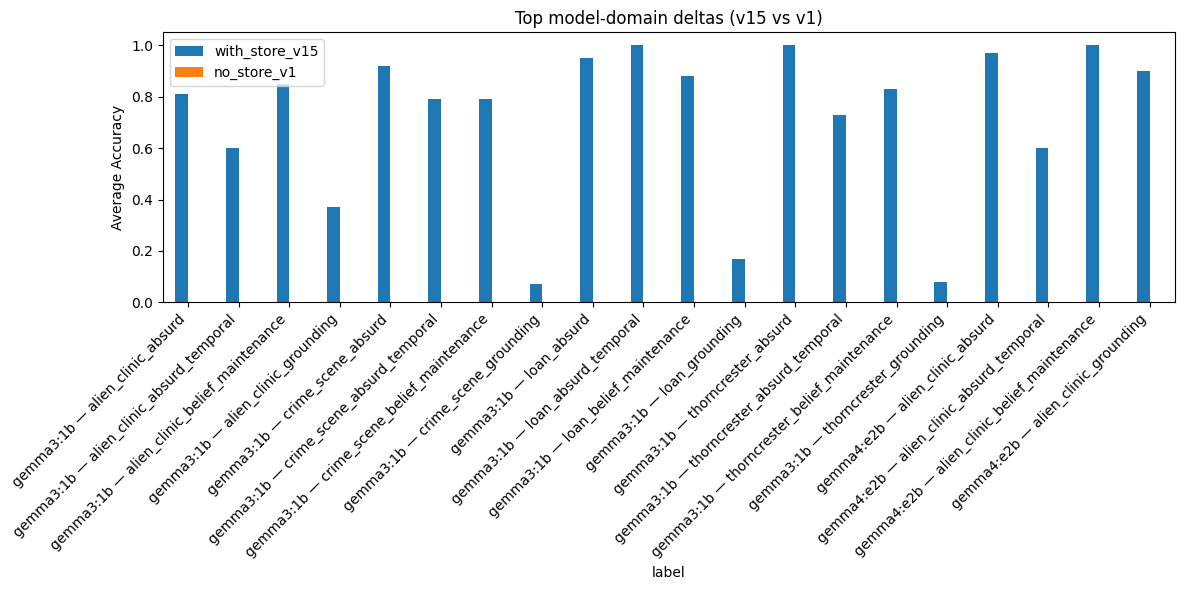

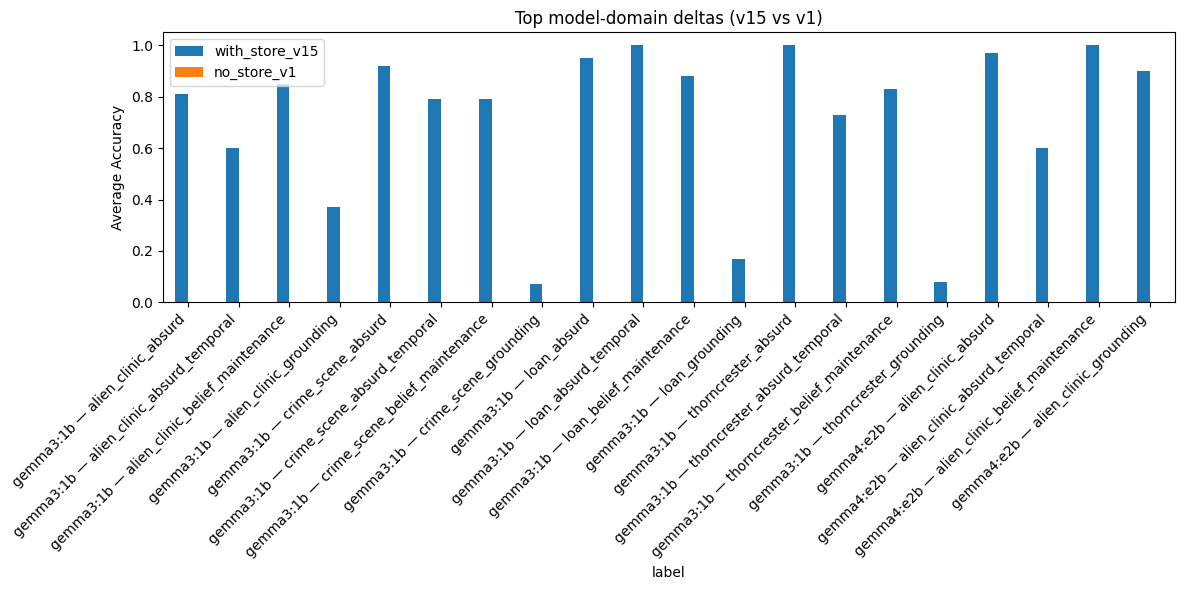

In [10]:
# ── 3a. v15 (With_Store) vs v1 (No_Store) ───────────────────────────────
comp = df_clean[df_clean[metric_column].astype(str).str.strip().str.lower() == "average_accuracy"].copy()

if "Eval_Prompt_Ver" in comp.columns:
    store_mask    = (comp["Condition"] == CONFIG["with_store_label"]) & (comp["Eval_Prompt_Ver"] == "v15")
    no_store_mask = (comp["Condition"] == CONFIG["no_store_label"])   & (comp["Eval_Prompt_Ver"] == "v1")
else:
    store_mask    = comp["Condition"] == CONFIG["with_store_label"]
    no_store_mask = comp["Condition"] == CONFIG["no_store_label"]

store_grp    = comp[store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].mean().rename(columns={"Value": "with_store_v15"})
no_store_grp = comp[no_store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].mean().rename(columns={"Value": "no_store_v1"})

merge_v15 = store_grp.merge(no_store_grp, on=[model_column, "Domain"], how="outer")
merge_v15["delta_v15_v1"] = merge_v15["with_store_v15"] - merge_v15["no_store_v1"]

model_v15 = merge_v15.groupby(model_column, as_index=False)[["with_store_v15", "no_store_v1"]].mean()
display(HTML("<h4>v15 vs v1 — model-level means</h4>"))
display(model_v15)

top15 = merge_v15.sort_values("delta_v15_v1").head(20).copy()
top15["label"] = top15[model_column].astype(str) + " — " + top15["Domain"].astype(str)
fig, ax = plt.subplots(figsize=(12, 6))
top15.set_index("label")[["with_store_v15", "no_store_v1"]].plot.bar(ax=ax)
ax.set_title("Top model-domain deltas (v15 vs v1)")
ax.set_ylabel("Average Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
display(fig)

,Model,with_store_v16,no_store_v2
0,gemma3:1b,0.44500,NaN
1,gemma4:e2b,0.75300,NaN
2,llama3.2:1b,0.30625,NaN
3,ministral-3:3b,0.79400,NaN
4,qwen3:4b (no-thinking),0.79550,NaN


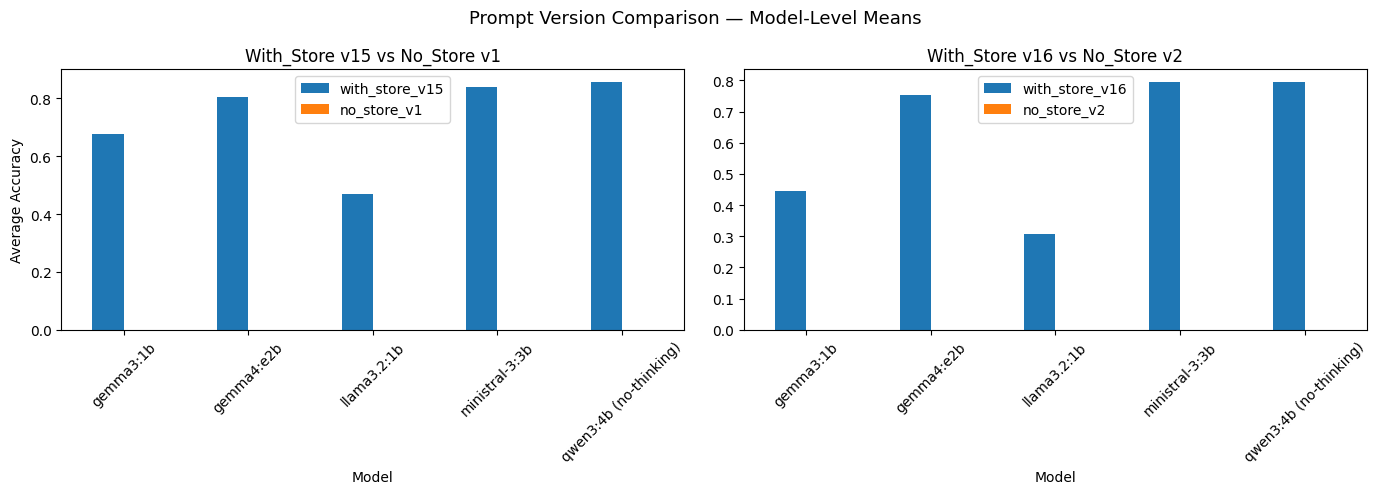

In [11]:
# ── 3b. v16 (With_Store) vs v2 (No_Store) ───────────────────────────────
comp2 = df_clean[df_clean[metric_column].astype(str).str.strip().str.lower() == "average_accuracy"].copy()

if "Eval_Prompt_Ver" in comp2.columns:
    store_mask    = (comp2["Condition"] == CONFIG["with_store_label"]) & (comp2["Eval_Prompt_Ver"] == "v16")
    no_store_mask = (comp2["Condition"] == CONFIG["no_store_label"])   & (comp2["Eval_Prompt_Ver"] == "v2")
else:
    store_mask    = comp2["Condition"] == CONFIG["with_store_label"]
    no_store_mask = comp2["Condition"] == CONFIG["no_store_label"]

store_grp    = comp2[store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].mean().rename(columns={"Value": "with_store_v16"})
no_store_grp = comp2[no_store_mask].groupby([model_column, "Domain"], as_index=False)["Value"].mean().rename(columns={"Value": "no_store_v2"})

merge_v16 = store_grp.merge(no_store_grp, on=[model_column, "Domain"], how="outer")
merge_v16["delta_v16_v2"] = merge_v16["with_store_v16"] - merge_v16["no_store_v2"]

model_v16 = merge_v16.groupby(model_column, as_index=False)[["with_store_v16", "no_store_v2"]].mean()
display(HTML("<h4>v16 vs v2 — model-level means</h4>"))
display(model_v16)

m15 = merge_v15.groupby(model_column, as_index=False)[["with_store_v15", "no_store_v1"]].mean()
m16 = model_v16

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if not m15.empty:
    m15.plot.bar(x=model_column, y=["with_store_v15", "no_store_v1"], ax=axes[0])
    axes[0].set_title("With_Store v15 vs No_Store v1")
    axes[0].set_ylabel("Average Accuracy")
    axes[0].tick_params(axis="x", rotation=45)
else:
    axes[0].text(0.5, 0.5, "v15 data not available", ha="center")

if not m16.empty:
    m16.plot.bar(x=model_column, y=["with_store_v16", "no_store_v2"], ax=axes[1])
    axes[1].set_title("With_Store v16 vs No_Store v2")
    axes[1].tick_params(axis="x", rotation=45)
else:
    axes[1].text(0.5, 0.5, "v16 data not available", ha="center")

plt.suptitle("Prompt Version Comparison — Model-Level Means", fontsize=13)
plt.tight_layout()
plt.show()
plt.close(fig)

## §4 — Hard Scenarios

Accuracy on `*_hard` domains for the three strongest models.

Condition,no_store,with_store,delta
Model,,,
gemma4:e2b,0.33375,0.5350,0.20125
ministral-3:3b,0.44875,0.5475,0.09875
qwen3:4b (no-thinking),0.40500,0.5450,0.14000


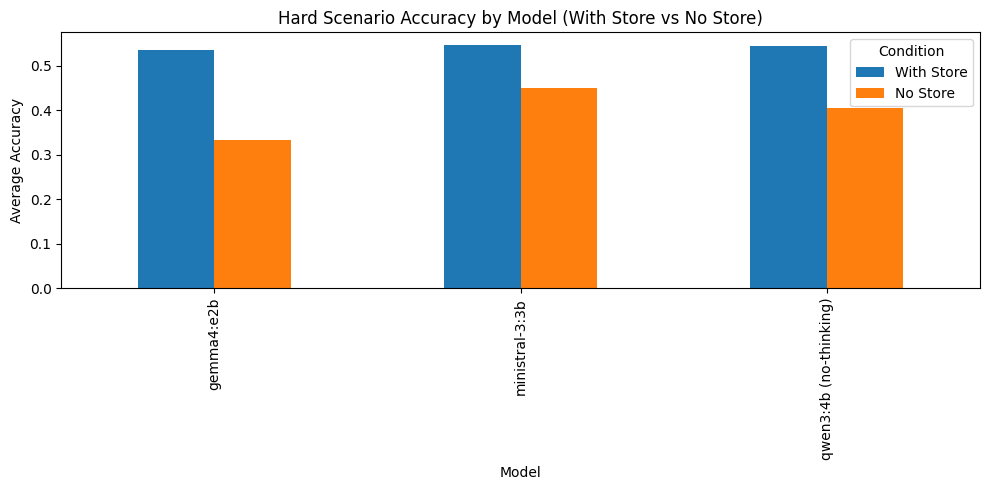

In [12]:
hard_models = ["ministral-3:3b", "gemma4:e2b", "qwen3:4b (no-thinking)"]

hard_df = df_clean[df_clean[metric_column].astype(str).str.strip().str.lower() == "average_accuracy"].copy()
hard_df = hard_df[hard_df["Domain"].astype(str).str.endswith("_hard")]
hard_df = hard_df[hard_df[model_column].isin(hard_models)]

if hard_df.empty:
    raise ValueError("No hard-accuracy rows found for the requested models")

hard_pivot = (
    hard_df.groupby([model_column, "Condition"], as_index=False)["Value"].mean()
    .pivot(index=model_column, columns="Condition", values="Value")
    .rename(columns={CONFIG["with_store_label"]: "with_store", CONFIG["no_store_label"]: "no_store"})
)
for col in ["with_store", "no_store"]:
    if col not in hard_pivot.columns:
        hard_pivot[col] = float("nan")

hard_pivot["delta"] = hard_pivot["with_store"] - hard_pivot["no_store"]
display(hard_pivot)

ax = hard_pivot[["with_store", "no_store"]].plot(kind="bar", figsize=(10, 5))
ax.set_title("Hard Scenario Accuracy by Model (With Store vs No Store)")
ax.set_xlabel("Model")
ax.set_ylabel("Average Accuracy")
ax.legend(["With Store", "No Store"], title="Condition")
plt.tight_layout()
plt.show()
plt.close(ax.figure)

## §5 — Calibration Metrics

Brier Score, ECE, and MacroCE per model. Lower is better.

In [13]:
metric_labels = {
    "AFR_Answer_Flip_Rate":       "AFR",
    "Summary_Metric_Brier_Score": "Brier",
    "Summary_Metric_ECE":         "ECE",
    "Summary_Metric_MacroCE":     "MacroECE",
}

metrics_df = df_clean[df_clean[metric_column].isin(metric_labels.keys())].copy()

metrics_summary = (
    metrics_df.groupby([model_column, "Condition", metric_column], as_index=False)["Value"].mean()
)

metrics_table = (
    metrics_summary
    .pivot(index=[model_column, "Condition"], columns=metric_column, values="Value")
    .rename(columns=metric_labels)
    .reset_index()
    .sort_values(by=[model_column, "Condition"])
)

def format_sigfigs(v: float, sig: int = 3) -> str:
    if pd.isna(v): return v
    return "0" if v == 0 else f"{v:.{sig}g}"

metrics_display = metrics_table.copy()
for col in metric_labels.values():
    if col in metrics_display.columns:
        metrics_display[col] = metrics_display[col].apply(lambda v: format_sigfigs(v * 100, 3))

display(metrics_display)

Summary_Metric,Model,Condition,AFR,Brier,ECE,MacroECE
0,gemma3:1b,No_Store,11.8,54,55.9,48.6
1,gemma3:1b,With_Store,4.38,35.7,36.8,45.2
2,gemma4:e2b,No_Store,7.83,33.6,33.8,45.1
3,gemma4:e2b,With_Store,1.99,20.2,20.4,33.3
4,llama3.2:1b,No_Store,7.63,36.2,41.9,52.8
5,llama3.2:1b,With_Store,6.97,32.6,34,44.3
6,ministral-3:3b,No_Store,8.99,29.1,28.5,45
7,ministral-3:3b,With_Store,2.42,16.3,16.7,34.9
8,qwen3:4b (no-thinking),No_Store,8.55,38.7,38.5,46.8
9,qwen3:4b (no-thinking),With_Store,1.54,16.9,16.9,33.5


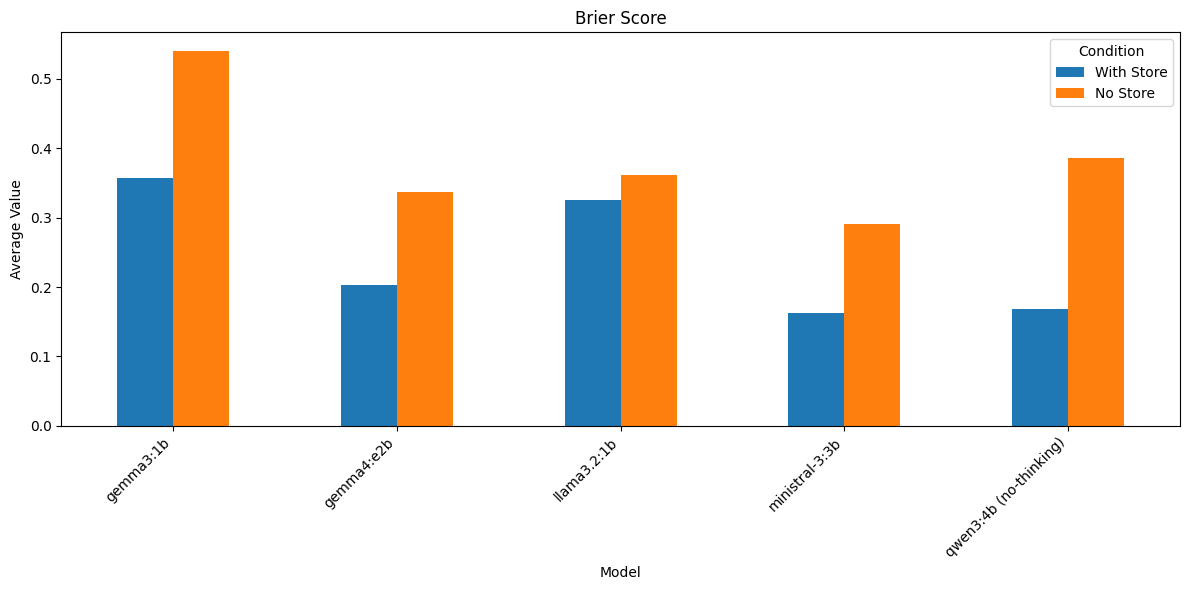

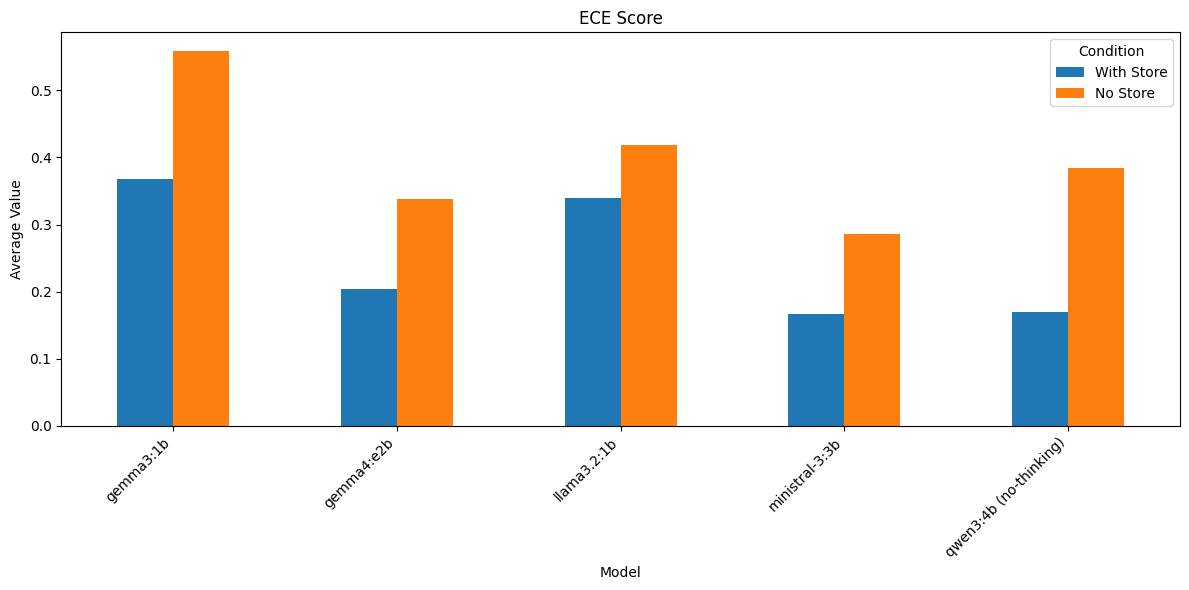

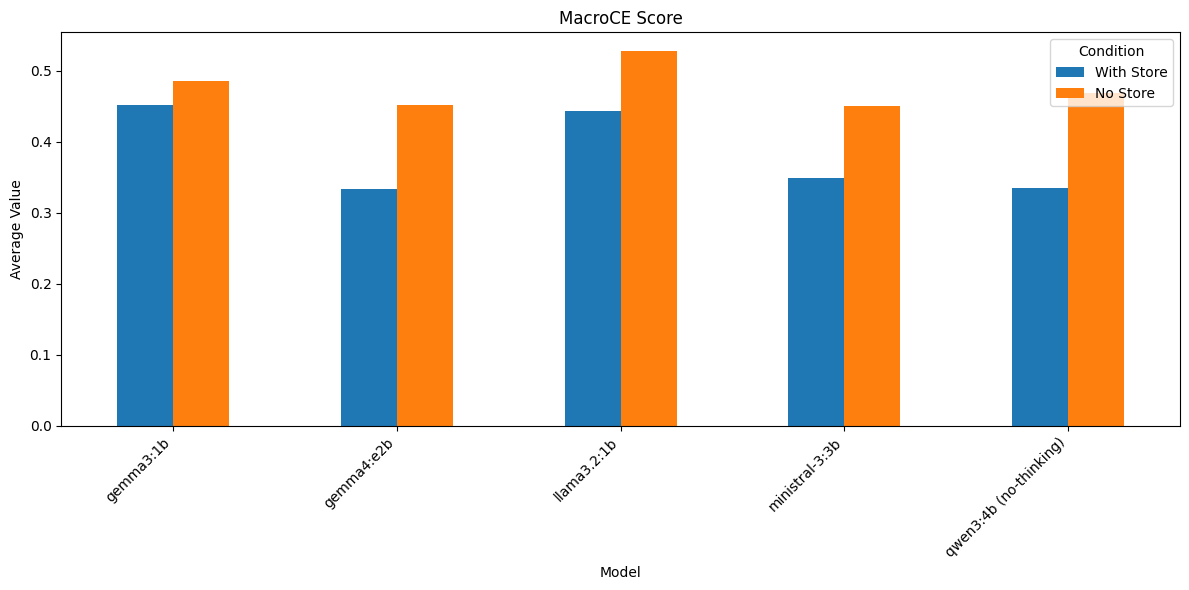

In [14]:
metric_chart_map = {
    "Summary_Metric_Brier_Score": "Brier Score",
    "Summary_Metric_ECE":         "ECE Score",
    "Summary_Metric_MacroCE":     "MacroCE Score",
}

metric_plot_df = df_clean[df_clean[metric_column].isin(metric_chart_map.keys())].copy()

for metric_key, metric_title in metric_chart_map.items():
    subset = metric_plot_df[metric_plot_df[metric_column] == metric_key]
    mpivot = (
        subset.groupby([model_column, "Condition"], as_index=False)["Value"].mean()
        .pivot(index=model_column, columns="Condition", values="Value")
        .rename(columns={CONFIG["with_store_label"]: "with_store", CONFIG["no_store_label"]: "no_store"})
    )
    for col in ["with_store", "no_store"]:
        if col not in mpivot.columns:
            mpivot[col] = float("nan")
    ax = mpivot[["with_store", "no_store"]].sort_index().plot(kind="bar", figsize=(12, 6))
    ax.set_title(metric_title)
    ax.set_xlabel("Model")
    ax.set_ylabel("Average Value")
    ax.legend(["With Store", "No Store"], title="Condition")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    plt.close(ax.figure)

In [15]:
# MacroCE vs ECE diagnostic — flags models where the two diverge most
mt = metrics_table.copy()

ece_col   = next((c for c in mt.columns if str(c).lower().strip() in ["ece", "summary_metric_ece"]),   None)
macro_col = next((c for c in mt.columns if str(c).lower().strip() in ["macroece", "macroce", "summary_metric_macroce"]), None)

if ece_col is None or macro_col is None:
    display(HTML("<b>ECE or MacroCE column not found in metrics_table.</b>"))
else:
    df_diag = mt.dropna(subset=[ece_col, macro_col]).copy()
    df_diag["delta_macro_minus_ece"] = df_diag[macro_col] - df_diag[ece_col]

    with_label = CONFIG["with_store_label"]
    dfw = df_diag[df_diag["Condition"] == with_label] if "Condition" in df_diag.columns else df_diag

    display(HTML("<h4>Top models where MacroCE − ECE is largest (With_Store)</h4>"))
    display(dfw.sort_values("delta_macro_minus_ece", ascending=False)[
        [model_column, macro_col, ece_col, "delta_macro_minus_ece"]
    ].head(20))

    if "Domain" in dfw.columns:
        avg_delta = dfw.groupby(model_column, as_index=False)["delta_macro_minus_ece"].mean().sort_values("delta_macro_minus_ece", ascending=False)
        display(HTML("<h4>Mean MacroCE − ECE per model (With_Store)</h4>"))
        display(avg_delta)

Summary_Metric,Model,MacroECE,ECE,delta_macro_minus_ece
7,ministral-3:3b,0.348975,0.166866,0.182109
9,qwen3:4b (no-thinking),0.334880,0.169207,0.165672
3,gemma4:e2b,0.332951,0.204170,0.128781
5,llama3.2:1b,0.442743,0.340088,0.102655
1,gemma3:1b,0.451669,0.368388,0.083282


## §6 — Delta Analysis (Δ = With_Store − No_Store)

Per model × domain accuracy delta. Negative deltas indicate scenarios where the store hurt performance.

In [16]:
delta_df = df_clean[
    df_clean[metric_column].astype(str).str.strip().str.lower() == "average_accuracy"
].copy()

delta_pivot = (
    delta_df.groupby([model_column, "Domain", "Condition"], as_index=False)["Value"].mean()
    .pivot(index=[model_column, "Domain"], columns="Condition", values="Value")
    .rename(columns={CONFIG["with_store_label"]: "with_store", CONFIG["no_store_label"]: "no_store"})
)

if "with_store" in delta_pivot.columns and "no_store" in delta_pivot.columns:
    delta_pivot["delta_store_minus_no_store"] = delta_pivot["with_store"] - delta_pivot["no_store"]

# Per-model summary stats
model_delta_summary = (
    delta_pivot.reset_index()
    .groupby(model_column, as_index=False)["delta_store_minus_no_store"]
    .agg(
        mean_delta   = "mean",
        median_delta = "median",
        negative_count = lambda s: (s < 0).sum(),
        positive_count = lambda s: (s > 0).sum(),
    )
    .sort_values("mean_delta")
)

display(HTML("<h4>Per-model delta summary</h4>"))
display(model_delta_summary)

display(HTML("<h4>10 worst model × domain pairs (Δ most negative)</h4>"))
display(delta_pivot.reset_index().sort_values("delta_store_minus_no_store").head(10))

,Model,mean_delta,median_delta,negative_count,positive_count
0,gemma3:1b,0.191562,0.2500,4,12
2,llama3.2:1b,0.213750,0.2300,1,15
3,ministral-3:3b,0.246250,0.2275,2,18
4,qwen3:4b (no-thinking),0.246500,0.1775,1,19
1,gemma4:e2b,0.269750,0.2975,1,19


Condition,Model,Domain,no_store,with_store,delta_store_minus_no_store
26,gemma4:e2b,loan_absurd,0.975,0.565,-0.410
7,gemma3:1b,crime_scene_grounding,0.345,0.035,-0.310
11,gemma3:1b,loan_grounding,0.310,0.115,-0.195
66,ministral-3:3b,loan_hard,0.820,0.695,-0.125
15,gemma3:1b,thorncrester_grounding,0.170,0.090,-0.080
75,qwen3:4b (no-thinking),alien_clinic_grounding,0.830,0.770,-0.060
43,llama3.2:1b,crime_scene_grounding,0.040,0.020,-0.020
3,gemma3:1b,alien_clinic_grounding,0.255,0.240,-0.015
71,ministral-3:3b,thorncrester_hard,0.400,0.390,-0.010
47,llama3.2:1b,loan_grounding,0.000,0.005,0.005


## §7 — Auxiliary Metrics

Answer Flip Rate (AFR), Extraction Failure Rate (EFR), and Evidence F1.

Condition,With_Store,No_Store
Model,,
gemma3:1b,0.043766,0.118063
gemma4:e2b,0.019908,0.078290
llama3.2:1b,0.069672,0.076300
ministral-3:3b,0.024207,0.089943
qwen3:4b (no-thinking),0.015415,0.085513


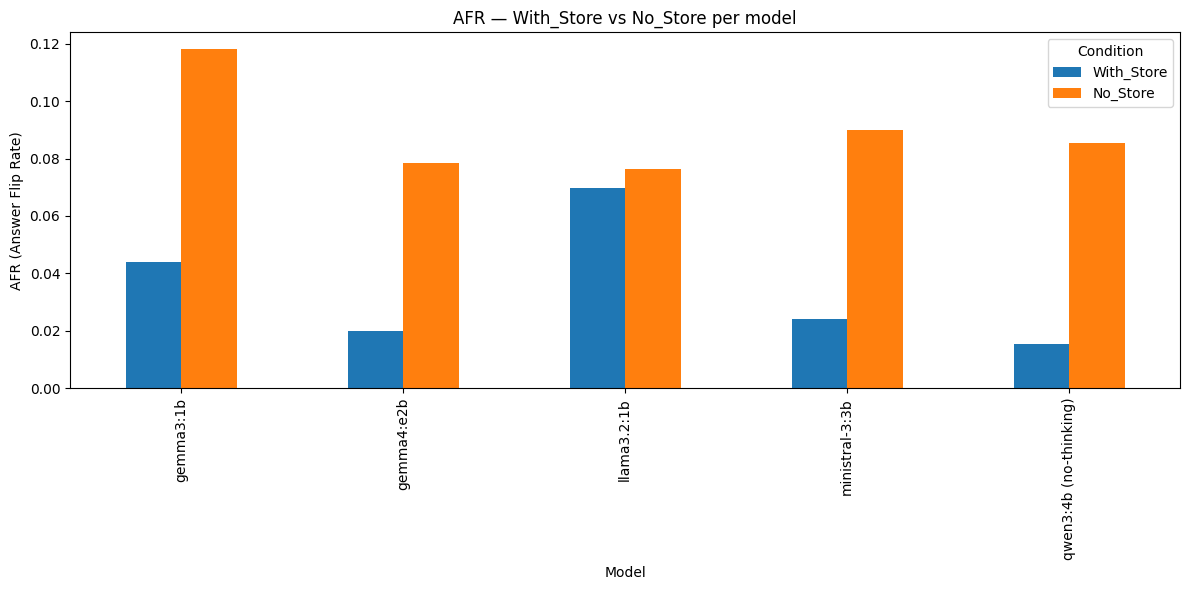

In [17]:
# ── 7a. AFR — Answer Flip Rate ───────────────────────────────────────────
with_label = CONFIG["with_store_label"]
no_label   = CONFIG["no_store_label"]

afr_df = df_clean[df_clean[metric_column] == "AFR_Answer_Flip_Rate"].copy()

if afr_df.empty:
    display(HTML("<b>No AFR rows found.</b>"))
else:
    afr_pivot = (
        afr_df.groupby([model_column, "Condition"], as_index=False)["Value"].mean()
        .pivot(index=model_column, columns="Condition", values="Value")
    )
    cols = [c for c in [with_label, no_label] if c in afr_pivot.columns]
    afr_pivot = afr_pivot[cols].rename(columns={with_label: "With_Store", no_label: "No_Store"})

    display(HTML("<h4>AFR (Answer Flip Rate): With_Store vs No_Store per model</h4>"))
    display(afr_pivot)

    ax = afr_pivot.plot(kind="bar", figsize=(12, 6))
    ax.set_title("AFR — With_Store vs No_Store per model")
    ax.set_ylabel("AFR (Answer Flip Rate)")
    plt.tight_layout()
    plt.show()
    plt.close(ax.figure)

In [22]:
# ── 7b. EFR — Extraction Failure Rate ────────────────────────────────────
efr = df_clean[df_clean[metric_column] == "EFR_Extraction_Failure_Rate"].copy()

if efr.empty:
    display(HTML("<b>No EFR rows found.</b>"))
else:
    efr["Value"] = pd.to_numeric(efr["Value"], errors="coerce")
    efr["Condition"] = efr["Condition"].replace({"WithStore": "With_Store", "NoStore": "No_Store"})

    per_model_cond = (
        efr.groupby([model_column, "Condition"], dropna=False)["Value"]
        .mean()
        .reset_index()
        .rename(columns={"Value": "Avg_EFR"})
    )
    per_model_cond["Avg_EFR"] = per_model_cond["Avg_EFR"].round(4)
    display(HTML("<h4>Average EFR per model and condition</h4>"))
    display(per_model_cond.sort_values("Avg_EFR", ascending=False))

    per_model_overall = (
        efr.groupby(model_column, dropna=False)["Value"]
        .mean()
        .reset_index()
        .rename(columns={"Value": "Avg_EFR_Overall"})
    )
    per_model_overall["Avg_EFR_Overall"] = per_model_overall["Avg_EFR_Overall"].round(4)
    display(HTML("<h4>Average EFR per model (overall)</h4>"))
    display(per_model_overall.sort_values("Avg_EFR_Overall", ascending=False))


,Model,Condition,Avg_EFR
4,llama3.2:1b,No_Store,0.4803
2,gemma4:e2b,No_Store,0.2518
1,gemma3:1b,With_Store,0.1981
5,llama3.2:1b,With_Store,0.1650
0,gemma3:1b,No_Store,0.1228
6,ministral-3:3b,No_Store,0.1085
3,gemma4:e2b,With_Store,0.0558
8,qwen3:4b (no-thinking),No_Store,0.0342
9,qwen3:4b (no-thinking),With_Store,0.0305
7,ministral-3:3b,With_Store,0.0205


,Model,Avg_EFR_Overall
2,llama3.2:1b,0.3227
0,gemma3:1b,0.1605
1,gemma4:e2b,0.1538
3,ministral-3:3b,0.0645
4,qwen3:4b (no-thinking),0.0324


,Model,v15,v16
0,gemma3:1b,0.461512,0.249181
1,gemma4:e2b,0.499650,0.546869
2,llama3.2:1b,0.200881,0.220919
3,ministral-3:3b,0.570945,0.381475
4,qwen3:4b (no-thinking),0.469155,0.364275


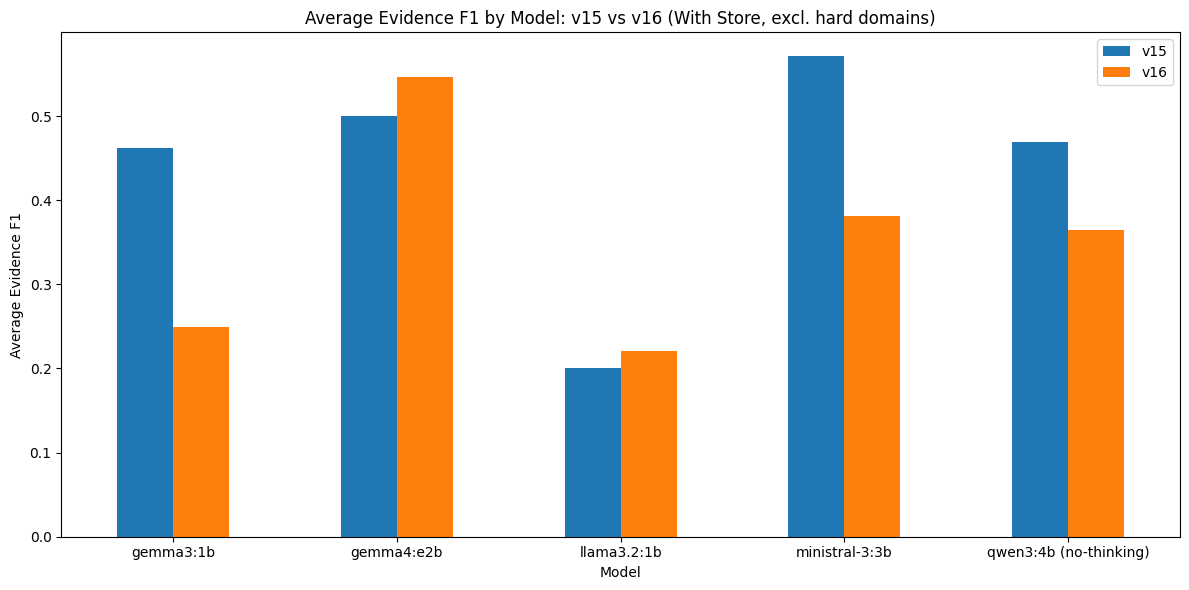

In [23]:
# ── 7c. Evidence F1 (v15 vs v16, With_Store, excluding _hard domains) ────────
ev_metric = "Average_Evidence_F1"

df_with_store_csv = pd.read_csv("eval_results_with_store.csv")

ver_col = "Eval_Prompt_Ver" if "Eval_Prompt_Ver" in df_with_store.columns else "Prompt_Ver"
filtered_ws = df_with_store[
    df_with_store[ver_col].astype(str).str.strip().str.lower() == "v15"
].copy() if ver_col in df_with_store.columns else df_with_store.copy()

def get_ev_f1(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    sub = df[df[metric_column].astype(str).str.strip() == ev_metric].copy()
    if sub.empty:
        return pd.DataFrame(columns=[model_column, "evidence_f1"])
    if model_column in sub.columns:
        sub[model_column] = sub[model_column].replace(rename_map)
    sub[value_col] = pd.to_numeric(sub[value_col], errors="coerce")
    return sub.groupby(model_column, as_index=False)[value_col].mean().rename(columns={value_col: "evidence_f1"})

v15_f1 = get_ev_f1(filtered_ws, "Value").rename(columns={"evidence_f1": "v15"})

pv_col = "Prompt_Ver" if "Prompt_Ver" in df_with_store_csv.columns else "Eval_Prompt_Ver"
v16_df = df_with_store_csv[
    df_with_store_csv[pv_col].astype(str).str.contains("v16", case=False, na=False)
    & ~df_with_store_csv["Domain"].astype(str).str.endswith("_hard")  # match v15 domain set
].copy() if pv_col in df_with_store_csv.columns else pd.DataFrame()

v16_val_col = "With_Store" if "With_Store" in v16_df.columns else "Value"
v16_f1 = get_ev_f1(v16_df, v16_val_col).rename(columns={"evidence_f1": "v16"}) if not v16_df.empty else pd.DataFrame(columns=[model_column, "v16"])

compare_f1 = v15_f1.merge(v16_f1, on=model_column, how="outer").sort_values(model_column)

if compare_f1.dropna(how="all", subset=["v15", "v16"]).empty:
    display(HTML("<b>No Evidence F1 data available.</b>"))
else:
    display(compare_f1)
    ax = compare_f1.set_index(model_column)[["v15", "v16"]].plot(kind="bar", figsize=(12, 6))
    ax.set_title("Average Evidence F1 by Model: v15 vs v16 (With Store, excl. hard domains)")
    ax.set_ylabel("Average Evidence F1")
    ax.set_xlabel("Model")
    plt.xticks(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()
    plt.close(ax.figure)


## §8 — Variability

Standard deviations of accuracy across runs and across domains/scenario types.

In [ ]:
# ── Per-model and per-scenario accuracy standard deviation ───────────────
# Shows how much accuracy fluctuates:
#   - Per model: spread across all the scenarios it was tested on
#   - Per scenario: spread across all models tested on it

spread_df = df_clean[
    df_clean[metric_column].astype(str).str.strip().str.lower() == "average_accuracy"
].copy()
spread_df["scenario_type"] = spread_df["Domain"].apply(extract_scenario_type)
spread_df = spread_df[spread_df["scenario_type"].isin(scenario_types)]
spread_df["Value"] = pd.to_numeric(spread_df["Value"], errors="coerce")

# ── Per-model: std across all domains ────────────────────────────────────
model_spread = (
    spread_df.groupby([model_column, "Condition"])["Value"]
    .agg(mean="mean", std="std")
    .unstack("Condition")
    .round(4)
)
model_spread.columns = [f"{stat}_{cond}" for stat, cond in model_spread.columns]
model_spread = model_spread.rename(columns={
    f"mean_{CONFIG['with_store_label']}": "WS_mean",
    f"std_{CONFIG['with_store_label']}":  "WS_std",
    f"mean_{CONFIG['no_store_label']}":   "NS_mean",
    f"std_{CONFIG['no_store_label']}":    "NS_std",
})

display(HTML("<h4>Per-model accuracy: mean ± std across all scenarios</h4>"))
display(model_spread[["NS_mean","NS_std","WS_mean","WS_std"]])

# ── Per-scenario: std across all models ──────────────────────────────────
scenario_spread = (
    spread_df.groupby(["scenario_type", "Condition"])["Value"]
    .agg(mean="mean", std="std")
    .unstack("Condition")
    .round(4)
)
scenario_spread.columns = [f"{stat}_{cond}" for stat, cond in scenario_spread.columns]
scenario_spread = scenario_spread.rename(columns={
    f"mean_{CONFIG['with_store_label']}": "WS_mean",
    f"std_{CONFIG['with_store_label']}":  "WS_std",
    f"mean_{CONFIG['no_store_label']}":   "NS_mean",
    f"std_{CONFIG['no_store_label']}":    "NS_std",
})

display(HTML("<h4>Per-scenario accuracy: mean ± std across all models</h4>"))
display(scenario_spread[["NS_mean","NS_std","WS_mean","WS_std"]])


,NS_mean,NS_std,WS_mean,WS_std
Model,,,,
gemma3:1b,0.3697,0.1529,0.5612,0.3122
gemma4:e2b,0.5090,0.2881,0.7787,0.2513
llama3.2:1b,0.1747,0.2126,0.3884,0.2496
ministral-3:3b,0.5712,0.2223,0.8175,0.1950
qwen3:4b (no-thinking),0.5800,0.2461,0.8265,0.1996


,NS_mean,NS_std,WS_mean,WS_std
scenario_type,,,,
absurd,0.4498,0.2627,0.8108,0.2629
absurd_temporal,0.3968,0.2247,0.7330,0.2358
belief_maintenance,0.6075,0.2999,0.8552,0.1985
grounding,0.4043,0.2955,0.4580,0.3388
hard,0.3958,0.1927,0.5425,0.1144


In [ ]:
# ── 8a. Per-model × scenario: std of accuracy across runs ────────────────
per_run_df = df_clean[
    df_clean[metric_column].astype(str).str.strip().str.lower() == "average_accuracy"
].copy()
per_run_df["scenario_type"] = per_run_df["Domain"].apply(extract_scenario_type)
per_run_df = per_run_df[per_run_df["scenario_type"].isin(scenario_types)]

per_run_var = (
    per_run_df.groupby([model_column, "scenario_type", "Condition"], as_index=False)["Value"]
    .std()
    .rename(columns={"Value": "std_accuracy"})
)

per_run_pivot = (
    per_run_var.pivot_table(index=[model_column, "scenario_type"], columns="Condition", values="std_accuracy")
    .reset_index()
    .rename(columns={CONFIG["with_store_label"]: "with_store", CONFIG["no_store_label"]: "no_store"})
)
per_run_pivot.columns.name = None
if "with_store" in per_run_pivot.columns and "no_store" in per_run_pivot.columns:
    per_run_pivot["delta_var"] = per_run_pivot["with_store"] - per_run_pivot["no_store"]

print("Per-model × scenario: StdDev of accuracy across runs")
display(per_run_pivot.sort_values([model_column, "scenario_type"]))

Per-model × scenario: StdDev of accuracy across runs


,Model,scenario_type,no_store,with_store,delta_var
0,gemma3:1b,absurd,0.213738,0.240476,0.026738
1,gemma3:1b,absurd_temporal,0.117587,0.203255,0.085667
2,gemma3:1b,belief_maintenance,0.105754,0.128779,0.023025
3,gemma3:1b,grounding,0.120238,0.111867,-0.008371
4,gemma4:e2b,absurd,0.295172,0.304862,0.009690
5,gemma4:e2b,absurd_temporal,0.284153,0.163527,-0.120626
6,gemma4:e2b,belief_maintenance,0.307292,0.017728,-0.289564
7,gemma4:e2b,grounding,0.268900,0.222032,-0.046868
8,gemma4:e2b,hard,0.189807,0.135436,-0.054371
9,llama3.2:1b,absurd,0.149857,0.197267,0.047410


In [ ]:
# ── 8b. Observation counts (sanity check) ───────────────────────────────
obs = (
    per_run_df.groupby([model_column, "scenario_type", "Condition"], as_index=False)["Value"]
    .count()
    .rename(columns={"Value": "n"})
    .pivot_table(index=[model_column, "scenario_type"], columns="Condition", values="n")
    .reset_index()
    .rename(columns={CONFIG["with_store_label"]: "with_store_n", CONFIG["no_store_label"]: "no_store_n"})
)
obs.columns.name = None
print("Observation counts per model / scenario / condition:")
display(obs)

Observation counts per model / scenario / condition:


,Model,scenario_type,no_store_n,with_store_n
0,gemma3:1b,absurd,8.0,8.0
1,gemma3:1b,absurd_temporal,8.0,8.0
2,gemma3:1b,belief_maintenance,8.0,8.0
3,gemma3:1b,grounding,8.0,8.0
4,gemma4:e2b,absurd,8.0,8.0
5,gemma4:e2b,absurd_temporal,8.0,8.0
6,gemma4:e2b,belief_maintenance,8.0,8.0
7,gemma4:e2b,grounding,8.0,8.0
8,gemma4:e2b,hard,8.0,8.0
9,llama3.2:1b,absurd,8.0,8.0


In [ ]:
# ── 8c. Aggregated std dev across all scenarios ──────────────────────────
std_df = df_clean[
    (df_clean[metric_column].astype(str).str.strip() == "StdDev_Raw_Score")
    & (df_clean["Domain"].apply(extract_scenario_type).isin(scenario_types))
].copy()
std_df["Value"] = pd.to_numeric(std_df["Value"], errors="coerce")

run_std_all = (
    std_df.groupby([model_column, "Condition"])["Value"].mean()
    .unstack().reset_index()
    .rename(columns={CONFIG["with_store_label"]: "with_store_std_runs", CONFIG["no_store_label"]: "no_store_std_runs"})
)

acc_df = df_clean[
    (df_clean[metric_column].astype(str).str.strip() == "Average_Accuracy")
    & (df_clean["Domain"].apply(extract_scenario_type).isin(scenario_types))
].copy()
acc_df["Value"] = pd.to_numeric(acc_df["Value"], errors="coerce")

domain_std_all = (
    acc_df.groupby([model_column, "Condition"])["Value"].std()
    .unstack().reset_index()
    .rename(columns={CONFIG["with_store_label"]: "with_store_std_scenarios", CONFIG["no_store_label"]: "no_store_std_scenarios"})
)

final_std = pd.merge(run_std_all, domain_std_all, on=model_column)
print("Standard Deviation per model (aggregated across all scenarios):")
display(final_std)

# ── 8d. Std dev of accuracy by scenario type ─────────────────────────────
scen_std_df = acc_df.copy()
scen_std_df["scenario_type"] = scen_std_df["Domain"].apply(extract_scenario_type)
scenario_std = scen_std_df.groupby(["scenario_type", "Condition"])["Value"].std().unstack().reset_index()
print("\nStd dev of Average_Accuracy by scenario type:")
display(scenario_std)

Standard Deviation per model (aggregated across all scenarios):


Condition,Model,no_store_std_runs,with_store_std_runs,no_store_std_scenarios,with_store_std_scenarios
0,gemma3:1b,0.819334,0.582372,0.152896,0.312232
1,gemma4:e2b,0.746792,0.275350,0.288140,0.251255
2,llama3.2:1b,0.417719,0.595119,0.212572,0.249556
3,ministral-3:3b,0.773018,0.296270,0.222309,0.194985
4,qwen3:4b (no-thinking),0.580895,0.283323,0.246108,0.199635



Std dev of Average_Accuracy by scenario type:


Condition,scenario_type,No_Store,With_Store
0,absurd,0.262683,0.262926
1,absurd_temporal,0.224709,0.235831
2,belief_maintenance,0.299921,0.198494
3,grounding,0.295504,0.338762
4,hard,0.192736,0.114408


## §9 — Data Quality Checks

Assertions and coverage audit. Run these if data changes.

In [ ]:
# ── 9a. Schema / condition assertions ───────────────────────────────────
expected_conditions = {CONFIG["with_store_label"], CONFIG["no_store_label"]}
actual_conditions   = set(df_clean["Condition"].dropna().unique())

assert actual_conditions <= expected_conditions, f"Unexpected conditions: {actual_conditions - expected_conditions}"
assert len(df_with_store) + len(df_no_store) <= len(df_clean)
assert (df_with_store["Condition"] == CONFIG["with_store_label"]).all()
assert (df_no_store["Condition"]   == CONFIG["no_store_label"]).all()

print("All assertions passed ✓")

All assertions passed ✓


In [ ]:
# ── 9b. Domain / prompt-version coverage audit ──────────────────────────
df_cov = pd.read_csv(CONFIG["csv_path"]).copy()

req_cols = ["Domain", "Model", "Eval_Prompt_Ver", "Baseline_Prompt_Ver"]
if any(c not in df_cov.columns for c in req_cols):
    print("Coverage check skipped: missing columns", [c for c in req_cols if c not in df_cov.columns])
else:
    df_cov["ev_norm"] = df_cov["Eval_Prompt_Ver"].astype(str).str.strip().str.lower()
    df_cov["bv_norm"] = df_cov["Baseline_Prompt_Ver"].astype(str).str.strip().str.lower()

    domains = sorted(df_cov["Domain"].dropna().unique())
    models  = sorted(df_cov["Model"].dropna().unique())
    check_eval_vs     = ["v16", "v15"]
    check_baseline_vs = ["v1", "v2"]
    hard_excluded_tokens = ["gemma3", "llama3.2"]

    for ev in check_eval_vs:
        present = set(df_cov.loc[df_cov["ev_norm"] == ev, "Domain"].dropna().unique())
        missing = [d for d in domains if d not in present]
        print(f"Eval {ev}: {len(missing)} domains missing")

    # Per-domain summary
    summary = [
        {"Domain": d,
         "eval_versions":     ", ".join(sorted(df_cov.loc[df_cov["Domain"]==d,"ev_norm"].dropna().unique())),
         "baseline_versions": ", ".join(sorted(df_cov.loc[df_cov["Domain"]==d,"bv_norm"].dropna().unique()))}
        for d in domains
    ]
    display(pd.DataFrame(summary).sort_values("Domain").reset_index(drop=True))

    # Per-model missing
    model_missing = []
    for m in models:
        mdf = df_cov[df_cov["Model"] == m]
        exclude_hard = any(t in str(m).lower() for t in hard_excluded_tokens)
        for ev in check_eval_vs:
            present = set(mdf.loc[mdf["ev_norm"] == ev, "Domain"].dropna().unique())
            miss = [d for d in domains if d not in present and (not exclude_hard or not d.endswith("_hard"))]
            if miss:
                model_missing.append({"Model": m, "type": "eval", "version": ev, "missing_domains": ", ".join(miss)})
        for bv in check_baseline_vs:
            present = set(mdf.loc[mdf["bv_norm"] == bv, "Domain"].dropna().unique())
            miss = [d for d in domains if d not in present and (not exclude_hard or not d.endswith("_hard"))]
            if miss:
                model_missing.append({"Model": m, "type": "baseline", "version": bv, "missing_domains": ", ".join(miss)})
    mm_df = pd.DataFrame(model_missing)
    if mm_df.empty:
        print("No model-level missing coverage detected ✓")
    else:
        display(mm_df.sort_values(["Model", "type", "version"]).reset_index(drop=True))

Eval v16: 0 domains missing
Eval v15: 0 domains missing


,Domain,eval_versions,baseline_versions
0,alien_clinic_absurd,"v15, v16","v1, v2"
1,alien_clinic_absurd_temporal,"v15, v16","v1, v2"
2,alien_clinic_belief_maintenance,"v15, v16","v1, v2"
3,alien_clinic_grounding,"v15, v16","v1, v2"
4,alien_clinic_hard,"v15, v16","v1, v2"
5,crime_scene_absurd,"v15, v16","v1, v2"
6,crime_scene_absurd_temporal,"v15, v16","v1, v2"
7,crime_scene_belief_maintenance,"v15, v16","v1, v2"
8,crime_scene_grounding,"v15, v16","v1, v2"
9,crime_scene_hard,"v15, v16","v1, v2"


No model-level missing coverage detected ✓


## §10 — Insights

- **Accuracy:** Using the belief store (`with_store`) increases Average Accuracy for most models, often substantially (e.g., Gemma, Ministral, Qwen variants).
- **Calibration:** Brier score, ECE, and MacroCE largely improve under `with_store`, indicating better-calibrated probabilities in many cases.
- **Scenario sensitivity:** The largest performance gains occur in `absurd` and `absurd_temporal_noise` scenarios and in belief-maintenance/grounding tasks.
- **Model variability:** Improvements vary by model and scenario; some models show modest gains while others show large, consistent improvements.
- **Hard scenarios:** Larger models (Gemma4, Ministral, Qwen3) benefit most from the store on hard domains; smaller models show mixed results.
- **Practical recommendation:** Prefer `with_store` for grounding- and belief-sensitive applications; run per-model statistical tests before production decisions.
- **Next steps:** (1) Add significance testing per model/scenario, (2) export per-model figures to `figures/`, (3) add a per-scenario CSV summary for downstream reporting.